# 🤖 CCIP — Giai đoạn 6: Predictive Modeling & Explainability
## Logistic Regression Baseline + LightGBM + SHAP + SQL DWH Consistency Analysis

**Kiến trúc Dữ liệu & Môi trường:**
- **Source of Truth:** PostgreSQL Data Warehouse (`dw.fact_loan`, `dw.dim_customer`, `dw.dim_region`)
- **ML Dataset:** `ccip_ml_dataset.parquet` (Grain Contract: 307,511 dòng, 1 row = 1 application)
- **Data Access:** Trực tiếp qua Google Drive (Colab) hoặc Local file Parquet

**Nội dung thực hiện:**
1. ✅ **6.3** Data Split — Train / Validation / Test (60 / 20 / 20, stratified)
2. ✅ **6.4** Logistic Regression Baseline — điểm tham chiếu phương pháp tuyến tính (Numeric + One-Hot Categorical)
3. ✅ **6.5** LightGBM Main Model — Early Stopping trên Validation Set (Test được cô lập hoàn toàn)
4. ✅ **6.6** Model Evaluation — AUC-ROC, PR-AUC, Classification Report trên Test Set
5. ✅ **6.7** Threshold Analysis — Phân tích trade-off Recall ↔ Precision trên Validation Set
6. ✅ **6.8** SHAP Explainability — Ước lượng global feature importance trên mẫu ngẫu nhiên 5,000 hồ sơ
7. ✅ **6.9** SQL DWH vs ML Consistency Analysis — Đối chiếu tính nhất quán giữa Descriptive BI và Predictive ML
8. ✅ **6.10** Limitations — Giới hạn phân tích theo chuẩn học thuật

---
> 💡 **Gợi ý:** Chạy mượt mà trên cả CPU hoặc T4 GPU (Google Colab).

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0️⃣ Cấu hình Tham số SSOT & Môi trường

In [10]:
# ─────────────────────────────────────────────────────────
# Cấu hình tham số Single Source of Truth (SSOT)
# Đồng bộ với Power BI & SQL Data Warehouse
# ─────────────────────────────────────────────────────────
SSOT_CONFIG = {
    'PORTFOLIO_DEFAULT_RATE': 0.0807,      # 8.07%
    'Q1_THRESHOLD': 0.6276,                # ext_score_avg >= 0.6276 (Lowest Risk)
    'Q2_THRESHOLD': 0.5144,                # 0.5144 <= ext_score_avg < 0.6276
    'Q3_THRESHOLD': 0.3868,                # 0.3868 <= ext_score_avg < 0.5144
    'Q4_THRESHOLD': 0.3868,                # ext_score_avg < 0.3868 (Highest Risk)
    'T1_AFFORDABILITY_THRESHOLD': 4.5,     # income_to_annuity < 4.5x (High Burden)
    'SHAP_SAMPLE_SIZE': 5000,              # Mẫu ước lượng SHAP
    'RANDOM_STATE': 42
}

print('✅ Đã nạp cấu hình SSOT Parameters:')
for k, v in SSOT_CONFIG.items():
    print(f'   {k:<30}: {v}')

✅ Đã nạp cấu hình SSOT Parameters:
   PORTFOLIO_DEFAULT_RATE        : 0.0807
   Q1_THRESHOLD                  : 0.6276
   Q2_THRESHOLD                  : 0.5144
   Q3_THRESHOLD                  : 0.3868
   Q4_THRESHOLD                  : 0.3868
   T1_AFFORDABILITY_THRESHOLD    : 4.5
   SHAP_SAMPLE_SIZE              : 5000
   RANDOM_STATE                  : 42


In [11]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Môi trường chạy: {"Google Colab" if IN_COLAB else "Local Jupyter"}')

# Kiểm tra GPU
try:
    import subprocess
    gpu_info = subprocess.check_output('nvidia-smi', shell=True).decode()
    print('✅ GPU khả dụng')
    USE_GPU = True
except:
    print('ℹ️ Sử dụng CPU (hoàn toàn ổn định và nhanh cho 307k dòng)')
    USE_GPU = False

Môi trường chạy: Google Colab
✅ GPU khả dụng


In [12]:
if IN_COLAB:
    print('📦 Cài đặt thư viện bổ trợ...')
    os.system('pip install -q lightgbm shap scikit-learn pyarrow fastparquet')
    print('✅ Hoàn tất cài đặt!')

📦 Cài đặt thư viện bổ trợ...
✅ Hoàn tất cài đặt!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print('✅ Đã nạp tất cả thư viện phân tích')
print(f'   LightGBM : {lgb.__version__}')
print(f'   SHAP     : {shap.__version__}')

✅ Đã nạp tất cả thư viện phân tích
   LightGBM : 4.6.0
   SHAP     : 0.52.0


## 1️⃣ Nạp Dữ liệu ML-Ready từ Parquet (SSOT từ DW)

Tập dữ liệu `ccip_ml_dataset.parquet` được trích xuất trực tiếp từ PostgreSQL Data Warehouse.
- Tất cả các biến Point-in-Time đã được chuẩn hóa tại DWH.
- Giữ nguyên vẹn **Data Grain Contract: 307,511 dòng (1 row = 1 loan application)**.

In [8]:
if IN_COLAB:
    from google.colab import drive
    print('📂 Mount Google Drive...')
    drive.mount('/content/drive')

    DATA_PATH = Path('/content/drive/MyDrive/CCIP/data/processed/ccip_ml_dataset.parquet')
    if not DATA_PATH.exists():
        DATA_PATH = Path('/content/ccip_ml_dataset.parquet')
else:
    DATA_PATH = Path('..') / 'data' / 'processed' / 'ccip_ml_dataset.parquet'

print(f'📖 Đọc dataset từ: {DATA_PATH}...')
df = pd.read_parquet(DATA_PATH)

print(f'\n✅ Nạp dữ liệu thành công!')
print(f'   Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'   Tỷ lệ vỡ nợ: {df["target"].mean()*100:.2f}% ({df["target"].sum():,} ca vỡ nợ)')

# Kiểm tra Data Grain Contract
assert len(df) == 307511, f'Lỗi Grain: Số dòng là {len(df):,}, không phải 307,511!'

📂 Mount Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📖 Đọc dataset từ: /content/drive/MyDrive/CCIP/data/processed/ccip_ml_dataset.parquet...

✅ Nạp dữ liệu thành công!
   Kích thước: 307,511 dòng × 50 cột
   Tỷ lệ vỡ nợ: 8.07% (24,825 ca vỡ nợ)


## 2️⃣ Định nghĩa Feature Universe & Point-in-Time Validation

Kiểm tra tính hợp lệ về mặt thời gian (Point-in-Time Validity):
- Toàn bộ các biến tín dụng bên ngoài (Bureau) và lịch sử vay cũ (Previous Application) đều là **thông tin lịch sử trước thời điểm nộp đơn hiện tại**.
- Loại bỏ các định danh (`loan_sk`, `customer_sk`, `customer_id`) để tránh rò rỉ dữ liệu.

In [14]:
# Danh sách các biến Numeric từ DW (34 biến)
NUMERIC_FEATURES = [
    'age_years',
    'amt_credit',
    'amt_income_total',
    'amt_annuity',
    'loan_to_value',
    'income_to_annuity',
    'ext_score_1', 'ext_score_2', 'ext_score_3', 'ext_score_avg',
    'years_employed',
    'has_employment',
    'cnt_children',
    'cnt_fam_members',
    'region_rating_client',
    'region_rating_client_w_city',
    'region_population_relative',
    'num_documents',
    'hour_appr_process_start',
    # Pre-application Bureau Summary
    'num_external_credits',
    'num_active_credits',
    'num_closed_credits',
    'total_active_credit_amt',
    'total_overdue_amt',
    'max_overdue_days',
    'pct_credits_overdue',
    'num_late_payment_months',
    'pct_late_months',
    # Pre-application Previous Application Summary
    'num_prev_applications',
    'num_approved',
    'num_refused',
    'approval_rate_pct',
    'avg_prev_credit_amt',
    'avg_days_since_prev_decision',
]

# Danh sách các biến Categorical từ DW (10 biến)
CATEGORICAL_FEATURES = [
    'contract_type',
    'code_gender',
    'name_income_type',
    'name_education_type',
    'name_family_status',
    'name_housing_type',
    'occupation_type',
    'flag_own_car',
    'flag_own_realty',
    'weekday_appr_process_start',
]

TARGET_COL = 'target'

num_cols = [c for c in NUMERIC_FEATURES if c in df.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]
ALL_FEATURES = num_cols + cat_cols

df_model = df[ALL_FEATURES + [TARGET_COL]].copy()
for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

print(f'Feature Universe: {len(ALL_FEATURES)} biến')
print(f'  Numeric    : {len(num_cols)}')
print(f'  Categorical: {len(cat_cols)}')

Feature Universe: 44 biến
  Numeric    : 34
  Categorical: 10


## 3️⃣ Data Split — 6.3 CCIP (60 / 20 / 20 Stratified)

```
307,511 hồ sơ
│
├── Train        60%  (~184,507 hồ sơ)  → Huấn luyện mô hình
├── Validation   20%  (~61,502  hồ sơ)  → Early Stopping & Phân tích Ngưỡng
└── Test         20%  (~61,502  hồ sơ)  → Đánh giá độc lập cuối cùng (Holdout)
```
> ⚠️ **Nguyên tắc:** Test Set không tham gia vào bất kỳ khâu huấn luyện hay chọn ngưỡng nào.

In [15]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET_COL]

# Bước 1: Tách Test Set (20% holdout)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SSOT_CONFIG['RANDOM_STATE'], stratify=y
)

# Bước 2: Tách Train (60%) và Validation (20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SSOT_CONFIG['RANDOM_STATE'], stratify=y_trainval
)

total = len(X)
print('=' * 58)
print('DATA SPLIT SUMMARY')
print('=' * 58)
print(f'  Train      : {X_train.shape[0]:>7,}  ({X_train.shape[0]/total*100:.1f}%)  — vỡ nợ: {y_train.mean()*100:.2f}%')
print(f'  Validation : {X_valid.shape[0]:>7,}  ({X_valid.shape[0]/total*100:.1f}%)  — vỡ nợ: {y_valid.mean()*100:.2f}%')
print(f'  Test       : {X_test.shape[0]:>7,}  ({X_test.shape[0]/total*100:.1f}%)  — vỡ nợ: {y_test.mean()*100:.2f}%')
print(f'  TOTAL      : {total:>7,}')
print('=' * 58)

DATA SPLIT SUMMARY
  Train      : 184,506  (60.0%)  — vỡ nợ: 8.07%
  Validation :  61,502  (20.0%)  — vỡ nợ: 8.07%
  Test       :  61,503  (20.0%)  — vỡ nợ: 8.07%
  TOTAL      : 307,511


## 4️⃣ Logistic Regression Baseline (Apples-to-Apples) — 6.4 CCIP

Xây dựng mô hình hồi quy tuyến tính chuẩn hóa sử dụng toàn bộ feature universe (Numeric + One-Hot Categorical) làm điểm đối chiếu công bằng cho LightGBM.

In [16]:
print('🔄 Huấn luyện Logistic Regression Baseline (Numeric + Categorical One-Hot)...')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=SSOT_CONFIG['RANDOM_STATE'],
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)

# Đánh giá baseline trên Test Set
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)
lr_ap   = average_precision_score(y_test, lr_prob)

print('=' * 50)
print('LOGISTIC REGRESSION BASELINE')
print('=' * 50)
print(f'  AUC-ROC            : {lr_auc:.4f}')
print(f'  Average Precision  : {lr_ap:.4f}')

🔄 Huấn luyện Logistic Regression Baseline (Numeric + Categorical One-Hot)...
LOGISTIC REGRESSION BASELINE
  AUC-ROC            : 0.7526
  Average Precision  : 0.2373


## 5️⃣ LightGBM Main Model — 6.5 CCIP

> ⚠️ **Lưu ý về `scale_pos_weight`:**  
> Trọng số bù mất cân bằng giúp tối ưu hóa AUC/Rank-ordering, tuy nhiên predicted probability đóng vai trò là **Risk Ranking Score**, không đồng nhất với xác suất default tuyệt đối khi chưa hiệu chỉnh (calibration).

In [17]:
neg_count    = (y_train == 0).sum()
pos_count    = (y_train == 1).sum()
scale_weight = neg_count / pos_count

lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'scale_pos_weight':  scale_weight,
    'random_state':      SSOT_CONFIG['RANDOM_STATE'],
    'n_jobs':            -1,
    'verbose':           -1,
}

print(f'Tỷ lệ cân bằng nhãn (scale_pos_weight): {scale_weight:.2f}x')
print('🚀 Huấn luyện LightGBM với Early Stopping trên Validation Set...')

import time
start = time.time()

model = lgb.LGBMClassifier(**lgb_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
    categorical_feature=cat_cols,
)

elapsed = time.time() - start
print(f'\n✅ Hoàn thành huấn luyện trong {elapsed:.1f}s')
print(f'   Số vòng tối ưu (Best Iteration): {model.best_iteration_}')

Tỷ lệ cân bằng nhãn (scale_pos_weight): 11.39x
🚀 Huấn luyện LightGBM với Early Stopping trên Validation Set...
[100]	valid_0's auc: 0.755557

✅ Hoàn thành huấn luyện trong 22.0s
   Số vòng tối ưu (Best Iteration): 115


## 6️⃣ Đánh giá Mô hình trên Test Set Holdout — 6.6 CCIP

In [18]:
y_prob    = model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

lgb_auc = roc_auc_score(y_test, y_prob)
lgb_ap  = average_precision_score(y_test, y_prob)

print('=' * 62)
print('BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH — TEST SET (HOLDOUT)')
print('=' * 62)
print(f'  Mô hình                   │  AUC-ROC  │  Avg Precision')
print(f'  ─────────────────────────┼───────────┼────────────────')
print(f'  Logistic Regression (LR) │  {lr_auc:.4f}  │  {lr_ap:.4f}')
print(f'  LightGBM (Main)          │  {lgb_auc:.4f}  │  {lgb_ap:.4f}')
gain_auc = (lgb_auc - lr_auc) * 100
print(f'  ─────────────────────────┼───────────┼────────────────')
print(f'  Mức tăng trưởng          │ +{gain_auc:.2f}pp  │')
print('=' * 62)

print('\nBáo cáo phân loại (LightGBM @ threshold = 0.50):')
print(classification_report(y_test, y_pred_05, target_names=['Không vỡ nợ', 'Vỡ nợ']))

BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH — TEST SET (HOLDOUT)
  Mô hình                   │  AUC-ROC  │  Avg Precision
  ─────────────────────────┼───────────┼────────────────
  Logistic Regression (LR) │  0.7526  │  0.2373
  LightGBM (Main)          │  0.7636  │  0.2535
  ─────────────────────────┼───────────┼────────────────
  Mức tăng trưởng          │ +1.10pp  │

Báo cáo phân loại (LightGBM @ threshold = 0.50):
              precision    recall  f1-score   support

 Không vỡ nợ       0.96      0.72      0.82     56538
       Vỡ nợ       0.17      0.67      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503



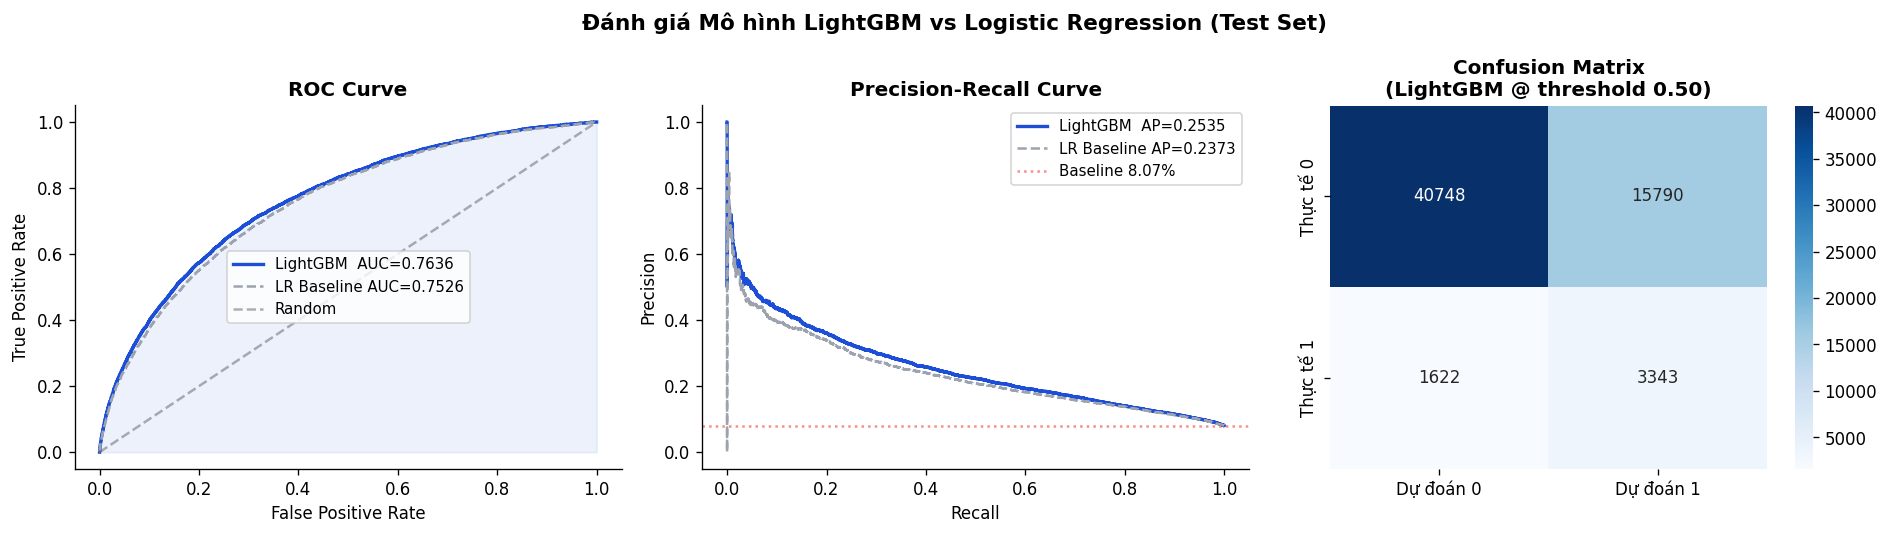

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Đánh giá Mô hình LightGBM vs Logistic Regression (Test Set)', fontsize=13, fontweight='bold')

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr_lgb, tpr_lgb, color='#1D4ED8', lw=2, label=f'LightGBM  AUC={lgb_auc:.4f}')
axes[0].plot(fpr_lr, tpr_lr, color='#9CA3AF', lw=1.5, linestyle='--', label=f'LR Baseline AUC={lr_auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.3, label='Random')
axes[0].fill_between(fpr_lgb, tpr_lgb, alpha=0.08, color='#1D4ED8')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(fontsize=9)

# Precision-Recall Curve
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, y_prob)
prec_lr, rec_lr, _   = precision_recall_curve(y_test, lr_prob)
baseline_rate = y_test.mean()
axes[1].plot(rec_lgb, prec_lgb, color='#1D4ED8', lw=2, label=f'LightGBM  AP={lgb_ap:.4f}')
axes[1].plot(rec_lr, prec_lr,   color='#9CA3AF', lw=1.5, linestyle='--', label=f'LR Baseline AP={lr_ap:.4f}')
axes[1].axhline(baseline_rate, color='#EF4444', linestyle=':', alpha=0.6, label=f'Baseline {baseline_rate*100:.2f}%')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(fontsize=9)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_05)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Dự đoán 0', 'Dự đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
axes[2].set_title('Confusion Matrix\n(LightGBM @ threshold 0.50)', fontweight='bold')

plt.tight_layout()
plt.show()

## 7️⃣ Phân tích Ngưỡng Quyết định trên Validation Set — 6.7 CCIP

> ⚠️ **Nguyên tắc:** Phân tích sự đánh đổi giữa Recall (độ bao phủ rủi ro), Precision (độ chính xác cảnh báo) và Tỷ lệ hồ sơ bị Flag được thực hiện trên **Validation Set** nhằm mục đích mô tả bức tranh vận hành. Không gán cứng threshold sản xuất khi chưa có Ma trận Chi phí Kinh doanh (Business Cost Matrix).

In [20]:
val_prob = model.predict_proba(X_valid)[:, 1]
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
threshold_results = []

for thr in thresholds:
    pred = (val_prob >= thr).astype(int)
    tp = ((pred == 1) & (y_valid == 1)).sum()
    fp = ((pred == 1) & (y_valid == 0)).sum()
    fn = ((pred == 0) & (y_valid == 1)).sum()
    flagged_n   = pred.sum()
    flagged_pct = flagged_n / len(pred) * 100
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    threshold_results.append({
        'Threshold': thr, 'Recall': recall, 'Precision': precision,
        'F1': f1, 'Flagged N': flagged_n, 'Flagged %': flagged_pct,
        'TP': tp, 'FP': fp,
    })

df_thr = pd.DataFrame(threshold_results)
print('=' * 80)
print('PHÂN TÍCH TRADE-OFF NGƯỠNG PHÂN LOẠI (Validation Set)')
print('=' * 80)
print(df_thr.to_string(
    index=False,
    formatters={
        'Threshold': '{:.2f}'.format,
        'Recall':    '{:.3f}'.format,
        'Precision': '{:.3f}'.format,
        'F1':        '{:.3f}'.format,
        'Flagged N': '{:,.0f}'.format,
        'Flagged %': '{:.1f}%'.format,
        'TP':        '{:,.0f}'.format,
        'FP':        '{:,.0f}'.format,
    }
))
print('=' * 80)

PHÂN TÍCH TRADE-OFF NGƯỠNG PHÂN LOẠI (Validation Set)
Threshold Recall Precision    F1 Flagged N Flagged %    TP     FP
     0.10  0.993     0.085 0.156    58,115     94.5% 4,928 53,187
     0.15  0.977     0.091 0.167    53,103     86.3% 4,849 48,254
     0.20  0.953     0.100 0.180    47,535     77.3% 4,731 42,804
     0.25  0.918     0.108 0.194    42,017     68.3% 4,557 37,460
     0.30  0.880     0.119 0.210    36,734     59.7% 4,371 32,363
     0.40  0.781     0.141 0.239    27,438     44.6% 3,877 23,561
     0.50  0.662     0.170 0.271    19,271     31.3% 3,285 15,986


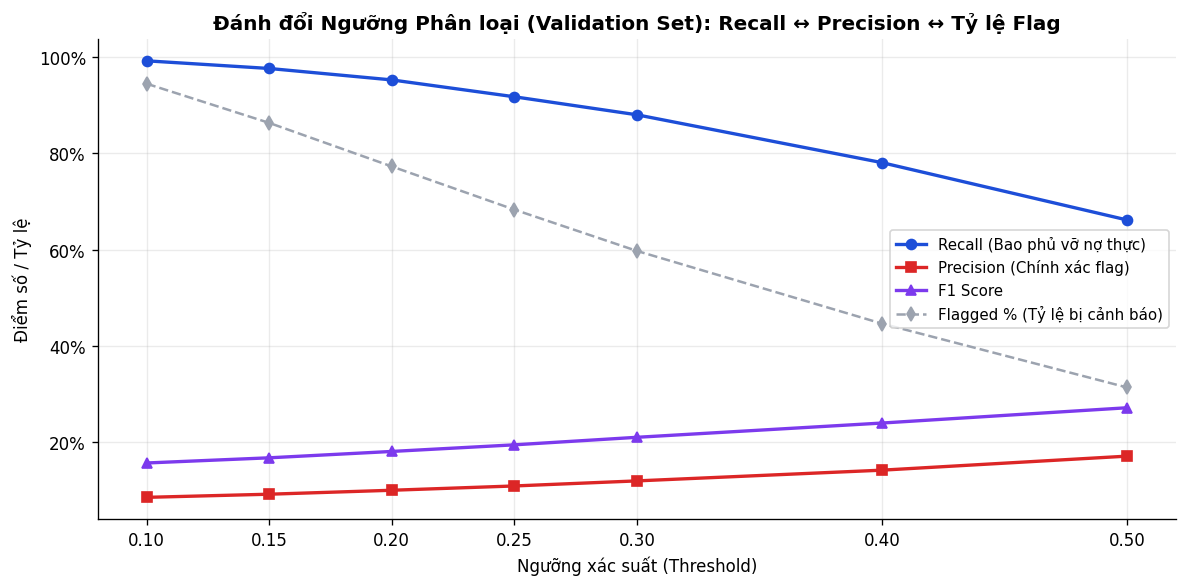

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thr['Threshold'], df_thr['Recall'],    'o-', color='#1D4ED8', lw=2, label='Recall (Bao phủ vỡ nợ thực)')
ax.plot(df_thr['Threshold'], df_thr['Precision'], 's-', color='#DC2626', lw=2, label='Precision (Chính xác flag)')
ax.plot(df_thr['Threshold'], df_thr['F1'],        '^-', color='#7C3AED', lw=2, label='F1 Score')
ax.plot(df_thr['Threshold'], df_thr['Flagged %'] / 100, 'd--', color='#9CA3AF', lw=1.5, label='Flagged % (Tỷ lệ bị cảnh báo)')

ax.set_xlabel('Ngưỡng xác suất (Threshold)')
ax.set_ylabel('Điểm số / Tỷ lệ')
ax.set_title('Đánh đổi Ngưỡng Phân loại (Validation Set): Recall ↔ Precision ↔ Tỷ lệ Flag', fontweight='bold')
ax.legend(loc='center right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(thresholds)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8️⃣ Giải thích Mô hình bằng SHAP (Explainability) — 6.8 CCIP

> 💡 **Phương pháp:** Sử dụng mẫu ngẫu nhiên **5,000 hồ sơ từ Test Set** để **ước lượng global feature importance** và giảm thiểu chi phí tính toán.

In [22]:
print(f'🔄 Tính toán SHAP values trên mẫu ngẫu nhiên {SSOT_CONFIG["SHAP_SAMPLE_SIZE"]:,} hồ sơ...')
import time
start = time.time()

X_shap = X_test.sample(min(SSOT_CONFIG['SHAP_SAMPLE_SIZE'], len(X_test)), random_state=SSOT_CONFIG['RANDOM_STATE'])

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'✅ Hoàn tất tính SHAP ({time.time()-start:.1f}s) trên {X_shap.shape[0]:,} mẫu')

🔄 Tính toán SHAP values trên mẫu ngẫu nhiên 5,000 hồ sơ...
✅ Hoàn tất tính SHAP (14.4s) trên 5,000 mẫu


In [23]:
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print('Top 15 biến có mức đóng góp dự đoán cao nhất (Mean |SHAP|):')
print('=' * 55)
for rank, (feat, val) in enumerate(mean_abs_shap.head(15).items(), 1):
    print(f'  {rank:>2}. {feat:<35} {val:.5f}')
print('=' * 55)

Top 15 biến có mức đóng góp dự đoán cao nhất (Mean |SHAP|):
   1. ext_score_avg                       0.43199
   2. ext_score_3                         0.15315
   3. loan_to_value                       0.13081
   4. years_employed                      0.11398
   5. ext_score_1                         0.11305
   6. ext_score_2                         0.10040
   7. occupation_type                     0.09257
   8. code_gender                         0.08905
   9. name_education_type                 0.08271
  10. flag_own_car                        0.07983
  11. amt_annuity                         0.07503
  12. age_years                           0.07222
  13. num_active_credits                  0.07098
  14. num_closed_credits                  0.06413
  15. amt_credit                          0.05982


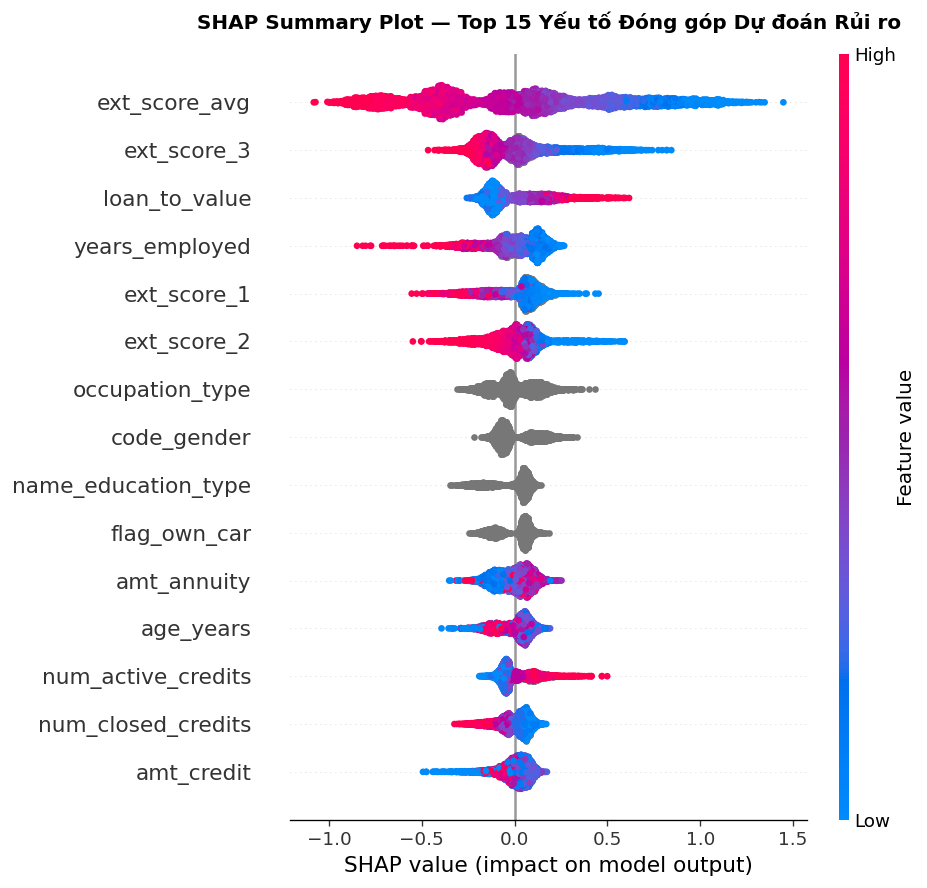

In [24]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, max_display=15, show=False)
plt.title('SHAP Summary Plot — Top 15 Yếu tố Đóng góp Dự đoán Rủi ro', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

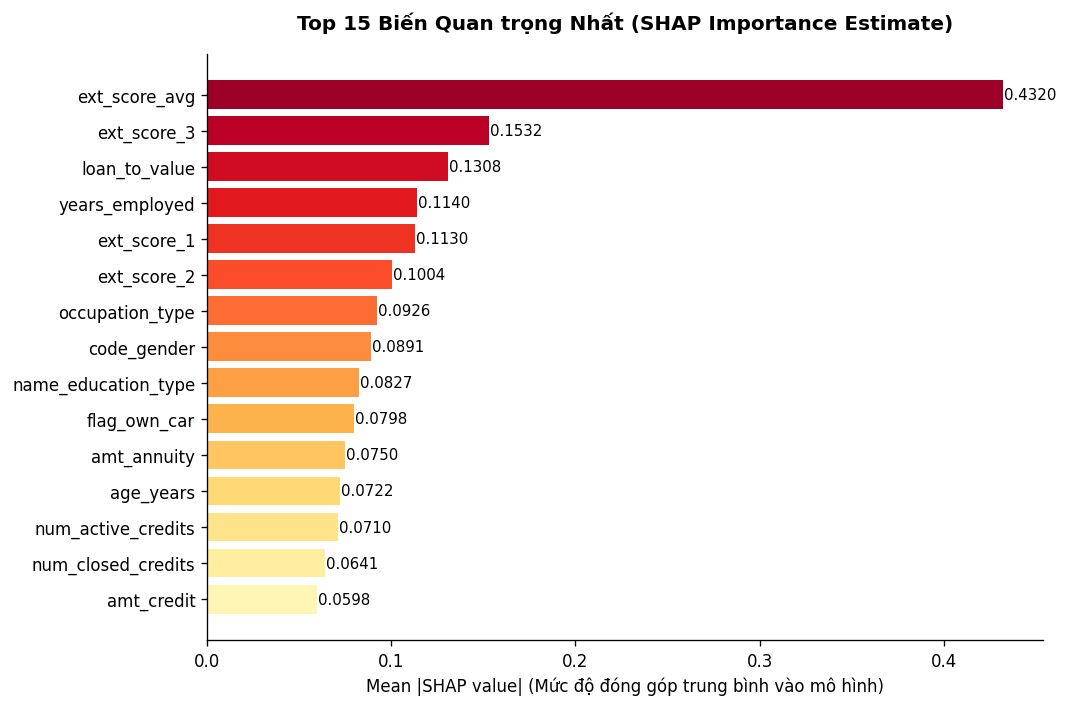

In [25]:
top_n = 15
top_features_shap = mean_abs_shap.head(top_n).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('YlOrRd', top_n)
bars = ax.barh(top_features_shap.index, top_features_shap.values, color=colors)
ax.set_xlabel('Mean |SHAP value| (Mức độ đóng góp trung bình vào mô hình)')
ax.set_title(f'Top {top_n} Biến Quan trọng Nhất (SHAP Importance Estimate)', fontweight='bold', pad=15)

for bar, val in zip(bars, top_features_shap.values):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9️⃣ SQL DWH vs ML Consistency Analysis — 6.9 CCIP

Kiểm định tính nhất quán giữa thống kê mô tả (Descriptive BI từ Data Warehouse) và kết quả dự đoán của máy học (Predictive ML).

In [26]:
# 1. Đối chiếu tương quan Pearson vs SHAP Importance
pearson_corr = X_test[num_cols].corrwith(y_test).abs().sort_values(ascending=False)

shap_imp_num = pd.Series(
    {col: np.abs(sv[:, list(X_shap.columns).index(col)]).mean()
     for col in num_cols if col in X_shap.columns}
).sort_values(ascending=False)

comparison = pd.DataFrame({
    'SHAP_rank':   range(1, len(shap_imp_num)+1),
    'SHAP_imp':    shap_imp_num.values,
    'Pearson_abs': pearson_corr.reindex(shap_imp_num.index).values
}, index=shap_imp_num.index)

print('Đối chiếu: SHAP importance vs Pearson correlation')
print(comparison.head(10).to_string(float_format=lambda x: f'{x:.4f}'))

Đối chiếu: SHAP importance vs Pearson correlation
                    SHAP_rank  SHAP_imp  Pearson_abs
ext_score_avg               1    0.4320       0.2229
ext_score_3                 2    0.1532       0.1792
loan_to_value               3    0.1308       0.0743
years_employed              4    0.1140       0.0740
ext_score_1                 5    0.1130       0.1552
ext_score_2                 6    0.1004       0.1640
amt_annuity                 7    0.0750       0.0131
age_years                   8    0.0722       0.0734
num_active_credits          9    0.0710       0.0686
num_closed_credits         10    0.0641       0.0366


In [27]:
# 2. Đối chiếu theo Risk Segment Q1–Q4 (sử dụng cấu hình SSOT)
X_test_cv = X_test.copy()
X_test_cv['y_true'] = y_test.values
X_test_cv['y_prob'] = y_prob

def assign_risk_segment(score):
    if pd.isna(score): return 'Unknown'
    if score >= SSOT_CONFIG['Q1_THRESHOLD']: return 'Q1 - Lowest Risk'
    if score >= SSOT_CONFIG['Q2_THRESHOLD']: return 'Q2 - Low-Moderate'
    if score >= SSOT_CONFIG['Q3_THRESHOLD']: return 'Q3 - Moderate-High'
    return 'Q4 - Highest Risk'

X_test_cv['risk_segment'] = X_test_cv['ext_score_avg'].apply(assign_risk_segment)

segment_summary = X_test_cv.groupby('risk_segment').agg(
    n                  = ('y_true', 'count'),
    actual_default_pct = ('y_true', lambda x: x.mean() * 100),
    pred_prob_avg      = ('y_prob', lambda x: x.mean() * 100),
).round(2)

sql_dr = {'Q1 - Lowest Risk': 2.71, 'Q2 - Low-Moderate': 4.58,
           'Q3 - Moderate-High': 7.71, 'Q4 - Highest Risk': 17.28}
segment_summary['sql_default_pct'] = segment_summary.index.map(sql_dr)
segment_summary['gap_pp'] = (segment_summary['actual_default_pct'] -
                              segment_summary['sql_default_pct']).round(2)

print('Đối chiếu: SQL Default Rate vs Test Set Actual vs ML Predicted Probability')
print('=' * 75)
print(segment_summary.to_string())
print('=' * 75)

Đối chiếu: SQL Default Rate vs Test Set Actual vs ML Predicted Probability
                        n  actual_default_pct  pred_prob_avg  sql_default_pct  gap_pp
risk_segment                                                                         
Q1 - Lowest Risk    14646                2.73          19.32             2.71    0.02
Q2 - Low-Moderate   17863                4.60          30.23             4.58    0.02
Q3 - Moderate-High  16472                8.44          45.35             7.71    0.73
Q4 - Highest Risk   12489               18.82          66.30            17.28    1.54
Unknown                33                6.06          45.21              NaN     NaN


In [28]:
# 3. Đối chiếu Hotspot Q4 × T1 (sử dụng cấu hình SSOT)
mask_hotspot = (
    (X_test_cv['income_to_annuity'] < SSOT_CONFIG['T1_AFFORDABILITY_THRESHOLD']) &
    (X_test_cv['ext_score_avg'] < SSOT_CONFIG['Q4_THRESHOLD'])
)

hotspot_n             = mask_hotspot.sum()
hotspot_actual_dr     = X_test_cv.loc[mask_hotspot, 'y_true'].mean() * 100
hotspot_pred_prob     = X_test_cv.loc[mask_hotspot, 'y_prob'].mean() * 100

print('Đối chiếu Q4 × T1 Hotspot:')
print(f'  SQL SSOT Default Rate : 19.91%')
print(f'  Test Set Actual DR    : {hotspot_actual_dr:.2f}%')
print(f'  ML Avg Pred Prob      : {hotspot_pred_prob:.2f}%')
print(f'  Chênh lệch (Gap)      : {abs(hotspot_actual_dr - 19.91):.2f}pp')

Đối chiếu Q4 × T1 Hotspot:
  SQL SSOT Default Rate : 19.91%
  Test Set Actual DR    : 19.90%
  ML Avg Pred Prob      : 67.48%
  Chênh lệch (Gap)      : 0.01pp


## 🏁 Kết luận & Giới hạn Mô hình — 6.10 Limitations

In [29]:
top5_shap = mean_abs_shap.head(5)

print('=' * 65)
print('CCIP — TỔNG KẾT MÔ HÌNH DỰ ĐOÁN & GIẢI THÍCH (GIAI ĐOẠN 6)')
print('=' * 65)

print('\n📊 HIỆU NĂNG MÔ HÌNH (Test Set Holdout — 20%):')
print(f'   Logistic Regression Baseline  │ AUC-ROC: {lr_auc:.4f}  │ AP: {lr_ap:.4f}')
print(f'   LightGBM Main Model           │ AUC-ROC: {lgb_auc:.4f}  │ AP: {lgb_ap:.4f}')

print('\n🔍 TOP 5 YẾU TỐ ĐÓNG GÓP CAO NHẤT (SHAP Estimate):')
for i, (feat, val) in enumerate(top5_shap.items(), 1):
    print(f'   {i}. {feat:<35} Mean|SHAP| = {val:.4f}')

print('\n⚠️ GIỚI HẠN MÔ HÌNH (Methodological Limitations):')
print('   1. Mục đích: Phân tích rủi ro phục vụ BI Insights, KHÔNG phải PD Basel Scorecard.')
print('   2. Đầu ra: Xác suất xếp hạng rủi ro (Risk Ranking), không tự động từ chối/cấp tín dụng.')
print('   3. SHAP thể hiện mức độ đóng góp dự đoán trong mô hình, không khẳng định quan hệ nhân quả (Causality).')
print('   4. Cần kết hợp Cost Matrix doanh nghiệp để chọn ngưỡng tối ưu.')
print('   5. Dữ liệu Point-in-time tại thời điểm nộp đơn.')
print('=' * 65)

CCIP — TỔNG KẾT MÔ HÌNH DỰ ĐOÁN & GIẢI THÍCH (GIAI ĐOẠN 6)

📊 HIỆU NĂNG MÔ HÌNH (Test Set Holdout — 20%):
   Logistic Regression Baseline  │ AUC-ROC: 0.7526  │ AP: 0.2373
   LightGBM Main Model           │ AUC-ROC: 0.7636  │ AP: 0.2535

🔍 TOP 5 YẾU TỐ ĐÓNG GÓP CAO NHẤT (SHAP Estimate):
   1. ext_score_avg                       Mean|SHAP| = 0.4320
   2. ext_score_3                         Mean|SHAP| = 0.1532
   3. loan_to_value                       Mean|SHAP| = 0.1308
   4. years_employed                      Mean|SHAP| = 0.1140
   5. ext_score_1                         Mean|SHAP| = 0.1130

⚠️ GIỚI HẠN MÔ HÌNH (Methodological Limitations):
   1. Mục đích: Phân tích rủi ro phục vụ BI Insights, KHÔNG phải PD Basel Scorecard.
   2. Đầu ra: Xác suất xếp hạng rủi ro (Risk Ranking), không tự động từ chối/cấp tín dụng.
   3. SHAP thể hiện mức độ đóng góp dự đoán trong mô hình, không khẳng định quan hệ nhân quả (Causality).
   4. Cần kết hợp Cost Matrix doanh nghiệp để chọn ngưỡng tối ưu.
   5